# Inventory optimization calculations

Using demand statistics from historical data and 90-day forecasts, we calculate three core inventory thresholds for each of the top 10 revenue categories.

**Formulas applied:**
- Safety Stock = Z × √(L × σ_d² + d̄² × σ_L²)
- Reorder Point (ROP) = (d̄ × L) + Safety Stock  
- Economic Order Quantity (EOQ) = √(2DS / H)

Where: d̄ = avg daily demand, L = avg lead time, σ = standard deviation,  
Z = 1.645 (95% service level), S = $50 order cost, H = 20% holding rate

> **Note:** Current inventory is simulated (seed=42). In a production deployment,
> this would be pulled live from a WMS or ERP system via API or database query.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/supply_chain_clean.csv', low_memory=False,
                 parse_dates=['order_date_dateorders'])

forecast_df = pd.read_csv('../data/forecast_results.csv', parse_dates=['ds'])

df_clean = df[
    ~((df['order_year'] == 2017) & (df['order_month'] >= 9)) &
    (df['order_year'] < 2018)
].copy()

print(f"Records: {len(df_clean):,}")
print(f"Categories: {df_clean['category_name'].nunique()}")

Records: 166,773
Categories: 31


In [2]:
# Daily demand per category
daily_cat = (df_clean
    .groupby(['category_name', df_clean['order_date_dateorders'].dt.date])
    .size()
    .reset_index(name='daily_orders'))

demand_stats = daily_cat.groupby('category_name').agg(
    avg_daily_demand = ('daily_orders', 'mean'),
    sigma_demand     = ('daily_orders', 'std')
).reset_index()

# Lead time and price stats
# Note: using days_for_shipping_real as a proxy for replenishment lead time
lead_stats = df_clean.groupby('category_name').agg(
    avg_lead_time   = ('days_for_shipping_real', 'mean'),
    sigma_lead_time = ('days_for_shipping_real', 'std'),
    avg_unit_price  = ('product_price', 'mean')
).reset_index()

inventory_base = demand_stats.merge(lead_stats, on='category_name')

# Focus on top 10 categories by revenue
top10 = (df_clean.groupby('category_name')['sales']
         .sum()
         .sort_values(ascending=False)
         .head(10)
         .index.tolist())

inventory_base = inventory_base[inventory_base['category_name'].isin(top10)].copy().reset_index(drop=True)

print("Demand and lead time stats:")
print(inventory_base[['category_name','avg_daily_demand','sigma_demand','avg_lead_time']].round(2).to_string(index=False))

Demand and lead time stats:
       category_name  avg_daily_demand  sigma_demand  avg_lead_time
    Camping & Hiking             13.63          3.73           3.50
    Cardio Equipment             12.41          3.59           3.49
              Cleats             24.42          5.15           3.51
         Electronics              3.87          1.90           3.49
             Fishing             17.19          4.21           3.51
Indoor/Outdoor Games             19.22          4.43           3.50
      Men's Footwear             22.13          4.87           3.50
       Shop By Sport             10.93          3.33           3.49
        Water Sports             15.40          4.05           3.49
     Women's Apparel             20.91          4.76           3.48


In [3]:
# Parameters
Z            = 1.645
ORDER_COST   = 50
HOLDING_RATE = 0.20

print(f"Service level: 95%  |  Z = {Z}  |  Order cost: ${ORDER_COST}  |  Holding rate: {HOLDING_RATE*100:.0f}%\n")

# Safety Stock
# Full formula: accounts for variability in both demand AND lead time
inventory_base['safety_stock'] = (
    Z * np.sqrt(
        inventory_base['avg_lead_time']    * inventory_base['sigma_demand']**2 +
        inventory_base['avg_daily_demand']**2 * inventory_base['sigma_lead_time']**2
    )
).round(1)

# Reorder Point
# ROP = expected demand during lead time + safety stock
inventory_base['reorder_point'] = (
    inventory_base['avg_daily_demand'] * inventory_base['avg_lead_time'] +
    inventory_base['safety_stock']
).round(1)

# Economic Order Quantity
# EOQ = sqrt(2 × annual demand × order cost / holding cost per unit)
inventory_base['annual_demand'] = (inventory_base['avg_daily_demand'] * 365).round(0)
inventory_base['holding_cost']  = (inventory_base['avg_unit_price'] * HOLDING_RATE).round(2)

inventory_base['eoq'] = np.sqrt(
    2 * inventory_base['annual_demand'] * ORDER_COST /
    inventory_base['holding_cost'].replace(0, np.nan)
).round(1)

# Days of supply covered at ROP
inventory_base['days_at_rop'] = (
    inventory_base['reorder_point'] / inventory_base['avg_daily_demand']
).round(1)

print("Inventory thresholds")
inventory_base[['category_name','safety_stock','reorder_point','eoq','days_at_rop']].round(2)

Service level: 95%  |  Z = 1.645  |  Order cost: $50  |  Holding rate: 20%

Inventory thresholds


,category_name,safety_stock,reorder_point,eoq,days_at_rop
0,Camping & Hiking,38.3,86.1,91.1,6.3
1,Cardio Equipment,34.9,78.3,151.9,6.3
2,Cleats,67.5,153.2,272.5,6.3
3,Electronics,11.9,25.4,133.8,6.6
4,Fishing,47.5,107.8,88.6,6.3
5,Indoor/Outdoor Games,53.2,120.4,264.9,6.3
6,Men's Footwear,60.8,138.3,176.2,6.3
7,Shop By Sport,31.1,69.3,221.7,6.3
8,Water Sports,43.0,96.7,118.6,6.3
9,Women's Apparel,57.6,130.4,276.3,6.2


In [4]:
# In a real deployment, current inventory comes from a WMS or ERP system.
# Here I simulate it with a fixed seed to make results reproducible.
np.random.seed(42)
inventory_base['current_inventory'] = (
    inventory_base['reorder_point'] * np.random.uniform(0.4, 4.5, len(inventory_base))
).round(0)

# Status classification
def classify(row):
    if row['current_inventory'] < row['reorder_point']:
        return 'Stockout risk'
    elif row['current_inventory'] > row['reorder_point'] * 3:
        return 'Overstock'
    return 'Healthy'

inventory_base['status']         = inventory_base.apply(classify, axis=1)
inventory_base['days_remaining'] = (
    inventory_base['current_inventory'] / inventory_base['avg_daily_demand']
).round(1)

print(inventory_base[['category_name','current_inventory','reorder_point',
                        'days_remaining','status']].to_string(index=False))
print(f"\n{inventory_base['status'].value_counts().to_string()}")

       category_name  current_inventory  reorder_point  days_remaining        status
    Camping & Hiking              167.0           86.1            12.3       Healthy
    Cardio Equipment              337.0           78.3            27.2     Overstock
              Cleats              521.0          153.2            21.3     Overstock
         Electronics               73.0           25.4            18.9       Healthy
             Fishing              112.0          107.8             6.5       Healthy
Indoor/Outdoor Games              125.0          120.4             6.5       Healthy
      Men's Footwear               88.0          138.3             4.0 Stockout risk
       Shop By Sport              274.0           69.3            25.1     Overstock
        Water Sports              277.0           96.7            18.0       Healthy
     Women's Apparel              431.0          130.4            20.6     Overstock

status
Healthy          5
Overstock        4
Stockout risk    1


## Inventory health snapshot

| Status | Count | Categories |
|--------|-------|------------|
| Stockout risk | 1 | Men's Footwear (4 days remaining) |
| Healthy | 5 | Water Sports, Camping & Hiking, Indoor/Outdoor Games, Fishing, Electronics |
| Overstock | 4 | Cleats (3.4× ROP), Women's Apparel, Cardio Equipment, Shop By Sport |

### Critical alerts

**Men's Footwear** has only 4 days of supply remaining against a lead time of ~3.5 days.
An immediate purchase order is required to avoid a stockout in a $2.9M revenue category.

**Fishing and Indoor/Outdoor Games** are both at 6.5 days remaining, sitting near their 
reorder points. One demand spike moves them into stockout risk territory. Recommend 
placing orders proactively.

**Cleats overstock** have 521 units on hand vs. a ROP of 153. Despite being the #2 revenue
category ($4.4M), excess stock represents tied-up working capital. Consider pausing 
replenishment orders until inventory normalises below 2× ROP.

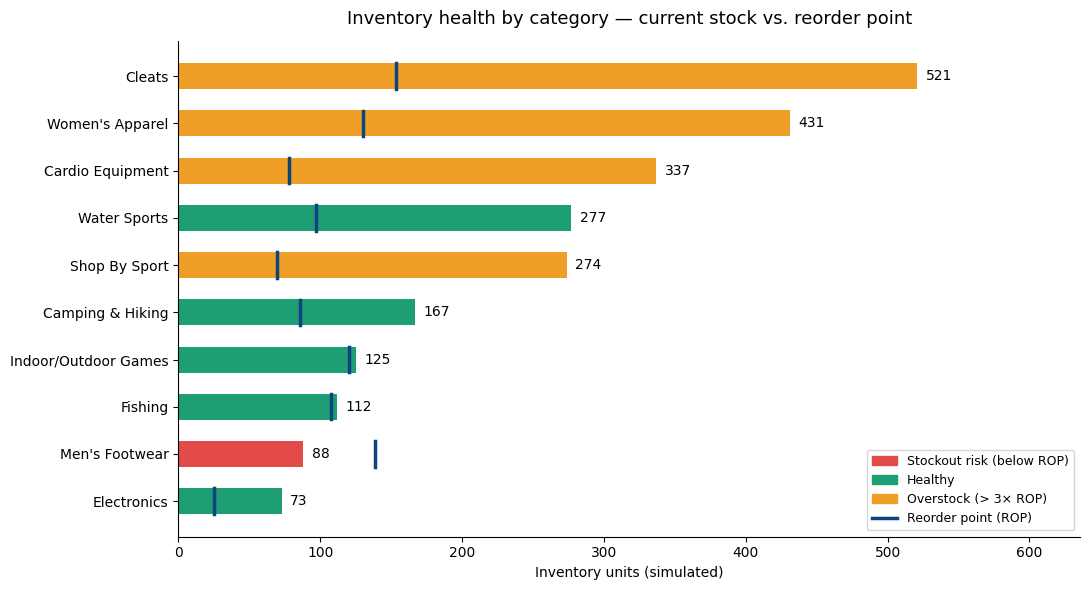

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = {'Stockout risk': '#E24B4A', 'Healthy': '#1D9E75', 'Overstock': '#EF9F27'}
inv_sorted = inventory_base.sort_values('current_inventory', ascending=True)
bar_colors = [colors[s] for s in inv_sorted['status']]

bars = ax.barh(inv_sorted['category_name'], inv_sorted['current_inventory'],
               color=bar_colors, height=0.55)

# Draw ROP marker as a vertical tick on each bar
for i, row in enumerate(inv_sorted.itertuples()):
    ax.plot([row.reorder_point, row.reorder_point], [i - 0.27, i + 0.27],
            color='#0C447C', linewidth=2.5, zorder=5)

ax.bar_label(bars,
             labels=[f"{int(v):,}" for v in inv_sorted['current_inventory']],
             padding=6, fontsize=10)

legend_elements = [
    mpatches.Patch(color='#E24B4A', label='Stockout risk (below ROP)'),
    mpatches.Patch(color='#1D9E75', label='Healthy'),
    mpatches.Patch(color='#EF9F27', label='Overstock (> 3× ROP)'),
    plt.Line2D([0], [0], color='#0C447C', linewidth=2.5, label='Reorder point (ROP)')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

ax.set_xlabel('Inventory units (simulated)')
ax.set_title('Inventory health by category — current stock vs. reorder point', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, inv_sorted['current_inventory'].max() * 1.22)

plt.tight_layout()
plt.savefig('../outputs/inventory_health.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Pull the 30-day ahead forecasts for the 3 categories modelled previously
forecast_30 = (forecast_df[
    (forecast_df['ds'] > '2017-08-31') &
    (forecast_df['ds'] <= '2017-09-30')]
    .groupby('category')['yhat']
    .mean()
    .reset_index()
    .rename(columns={'category': 'category_name', 'yhat': 'forecast_30d_avg'}))

inventory_final = inventory_base.merge(forecast_30, on='category_name', how='left')

# For categories without a dedicated forecast, fall back to historical average
inventory_final['forecast_30d_avg'] = inventory_final['forecast_30d_avg'].fillna(
    inventory_final['avg_daily_demand']
)

inventory_final['demand_vs_historical_pct'] = (
    (inventory_final['forecast_30d_avg'] - inventory_final['avg_daily_demand']) /
    inventory_final['avg_daily_demand'] * 100
).round(1)

inventory_final[['category_name','avg_daily_demand',
                  'forecast_30d_avg','demand_vs_historical_pct']].round(2)

,category_name,avg_daily_demand,forecast_30d_avg,demand_vs_historical_pct
0,Camping & Hiking,13.63,14.10,3.5
1,Cardio Equipment,12.41,12.41,0.0
2,Cleats,24.42,24.78,1.5
3,Electronics,3.87,3.87,0.0
4,Fishing,17.19,16.63,-3.2
5,Indoor/Outdoor Games,19.22,19.22,0.0
6,Men's Footwear,22.13,22.13,0.0
7,Shop By Sport,10.93,10.93,0.0
8,Water Sports,15.40,15.40,0.0
9,Women's Apparel,20.91,20.91,0.0


In [8]:
export_cols = [
    'category_name', 'avg_daily_demand', 'sigma_demand',
    'avg_lead_time', 'avg_unit_price', 'safety_stock',
    'reorder_point', 'eoq', 'days_at_rop', 'annual_demand',
    'current_inventory', 'days_remaining', 'status',
    'forecast_30d_avg', 'demand_vs_historical_pct'
]

inventory_final[export_cols].to_csv('../data/inventory_optimization.csv', index=False)
print("Saved to data/inventory_optimization.csv")

print(f"Stockout risk:  {(inventory_final['status'] == 'Stockout risk').sum()} categories")
print(f"Healthy:        {(inventory_final['status'] == 'Healthy').sum()} categories")
print(f"Overstock:      {(inventory_final['status'] == 'Overstock').sum()} categories")

Saved to data/inventory_optimization.csv
Stockout risk:  1 categories
Healthy:        5 categories
Overstock:      4 categories


---

## Summary

| Metric | Value |
|--------|-------|
| Categories analysed | 10 (top 10 by revenue) |
| Service level | 95% (Z = 1.645) |
| Stockout risk | 1 category — Men's Footwear |
| Overstock | 4 categories — Cleats most severe (3.4× ROP) |
| Most urgent | Men's Footwear: 4 days supply remaining |
| Watchlist | Fishing, Indoor/Outdoor Games: 6.5 days remaining |

**Output:** `data/inventory_optimization.csv`